# Podcast RAG

## Overview

This sample demonstrates a Retrieval-Augmented Generation (RAG) system using a **Podcast episode** as the knowledge base, with text query capability.
Initially an RSS feed link will be the input to allow the user to select and download a specific podcast episode. The selected audio undergoes preprocessing steps such as resampling and chunking to prepare it for transcription. 
Each chunk is transcribed to text using the [**Whisper base model**](https://huggingface.co/openai/whisper-base) via an Automatic Speech Recognition (ASR) pipeline optimized to run on **Intel® Core™ Ultra Processors** with [**PyTorch XPU backend**](https://pytorch.org/docs/stable/notes/get_start_xpu.html) for hardware acceleration. These transcriptions are then embedded using [**Teapot LLM**](https://huggingface.co/teapotai/teapotllm), creating a knowledge base.
User queries are handled by the Teapot RAG system so that it retrieves a relevant text response. 

## Workflow

- User provides an `RSS feed URL` to list available podcast episodes.
- The selected audio podcast episode is downloaded, resampled and then split into chunks.
- Each chunk is transcribed to text using the [*Whisper base model*](https://huggingface.co/openai/whisper-base) (ASR).
- Transcribed text chunks are embedded using the [*Teapot LLM*](https://huggingface.co/teapotai/teapotllm) to create a searchable knowledge base.
- A text query from the user is processed by the Teapot LLM RAG system, to get a relevant text response.

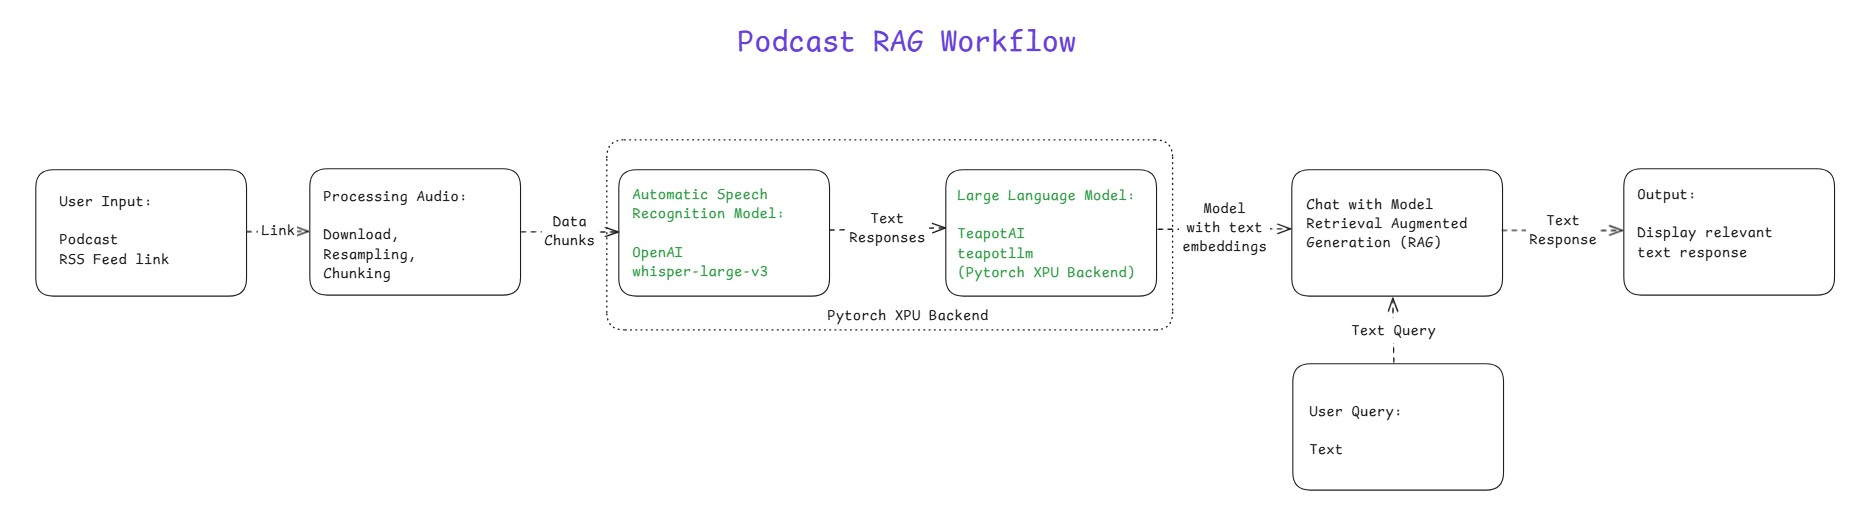

## Import necessary packages

Import all the necessary packages and libraries

In [19]:
import os
import torch
import logging
import requests
import feedparser
import torchaudio
import ipywidgets as widgets
from teapotai import TeapotAI
from urllib.parse import urlparse
from IPython.display import display
from huggingface_hub import notebook_login
from transformers import WhisperProcessor, WhisperForConditionalGeneration

logging.basicConfig(level=logging.INFO)

## Login to Huggingface to download the models (Optional)
- Log in to [Huggingface](https://huggingface.co/) using your credentials.
- You’ll need a [User Access Token](https://huggingface.co/docs/hub/security-tokens), which you can generate from your [Settings](https://huggingface.co/settings/tokens) page. This token is used to authenticate your identity with the Hugging Face Hub.
- Once you've generated the token, copy it and keep it secure. Then, run the cell below and paste your access token when prompted.

In [20]:
notebook_login()

## Select podcast episode
Select the episode from the Podcast RSS Feed URL.

In [2]:
def select_podcast_episode(PODCAST_URL):
    """
    Fetches and displays a dropdown widget to select an episode.

    Returns:
        dropdown: IPython widget for selecting podcast episode.
    """
    try:
        VALID_EXTENSIONS = ['.xml', '.rss']
        if any(PODCAST_URL.lower().endswith(ext) for ext in VALID_EXTENSIONS):
            logging.info(f" Found podcast URL.")    	
            feed = feedparser.parse(PODCAST_URL)
            episodes = []
            for entry in feed.entries:
                audio_url = None
                if not audio_url and hasattr(entry, 'enclosures') and entry.enclosures:
                    audio_url = entry.enclosures[0].href
                if audio_url:
                    episodes.append({'title': entry.title, 'url': audio_url})
            logging.info(f" Found {len(episodes)} episodes")
            episode_titles = [ep['title'] for ep in episodes]
            dropdown = widgets.Dropdown(
                options=episode_titles,
                value=episode_titles[0],
                description='Episode:'
            )
            display(dropdown)
            return dropdown, episodes
        else:
        	logging.info(f" Invalid podcast URL. Must end with one of: {VALID_EXTENSIONS}")
    except Exception as e:
        logging.exception(f" Error while selecting the podcast: {str(e)}")

In [3]:
PODCAST_URL = "https://feed.podbean.com/openatintel/feed.xml"
dropdown, episodes = select_podcast_episode(PODCAST_URL)

INFO:root: Found podcast URL.
INFO:root: Found 100 episodes


Dropdown(description='Episode:', options=('Building Innovation with Open Source AI', 'Democratizing Kubernetes…

## Download Audio
Download the selected podcast episode

In [4]:
def download_selected_audio(dropdown, episodes):
    """
    """
    try:
        OUTPUT_DIR = "downloads"
        selected_index = dropdown.index
        selected_url = episodes[selected_index]['url']
        logging.info(f" Selected episode: {episodes[selected_index]['title']}")
        logging.info(f" Audio URL: {selected_url}")
        logging.info(f" Downloading audio from: {selected_url}")
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        filename = os.path.basename(urlparse(selected_url).path)
        audio_path = os.path.join(OUTPUT_DIR, filename)
        response = requests.get(selected_url)
        with open(audio_path, 'wb') as f:
            f.write(response.content)
        logging.info(f" Audio saved to: {audio_path}")
        return audio_path
    except Exception as e:
        logging.exception(f" Error while downloading the podcast: {str(e)}")

In [5]:
audio_path = download_selected_audio(dropdown, episodes)

INFO:root: Selected episode: Building Innovation with Open Source AI
INFO:root: Audio URL: https://mcdn.podbean.com/mf/web/39af5nsnhjy8ckxr/OpenAtIntel_Ep111_MelissaMcKay-JFrog.mp3
INFO:root: Downloading audio from: https://mcdn.podbean.com/mf/web/39af5nsnhjy8ckxr/OpenAtIntel_Ep111_MelissaMcKay-JFrog.mp3
INFO:root: Audio saved to: downloads\OpenAtIntel_Ep111_MelissaMcKay-JFrog.mp3


## Initialize Audio Models
Initialize [*Whisper base model*](https://huggingface.co/openai/whisper-base) via Automatic Speech Recognition (ASR) pipeline.

In [6]:
def initialize_audio_models():
    """
    Initialize Automatic Speech Recognition (ASR) model.

    Returns:
        model:
        processor: 
    Raises:
        Exception: Raises an exception if there is any error while loading the ASR model.
    """
    try:
        model_id = "openai/whisper-base"
        device = "xpu" if torch.xpu.is_available() else "cpu"
        processor = WhisperProcessor.from_pretrained(pretrained_model_name_or_path=model_id)
        model = WhisperForConditionalGeneration.from_pretrained(pretrained_model_name_or_path=model_id)
        model = model.to(device)
        logging.info(" Model loaded!")
        return model, processor
    except Exception as e:
        logging.exception(f" Error while selecting the podcast: {str(e)}")

In [7]:
model, processor = initialize_audio_models()

INFO:root: Model loaded!


In [8]:
def process_podcast_audio(audio_path, model, processors):
    """
    """
    try:
        waveform, sample_rate = torchaudio.load(audio_path)
        logging.info(f" Original sample rate: {sample_rate} Hz")
        logging.info(f" Audio shape: {waveform.shape}")
        
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            logging.info(" Converted stereo to mono")
        
        if sample_rate != 16000:
            resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform = resampler(waveform)
            sample_rate = 16000
            logging.info(" Resampled to 16kHz")
            logging.info(f" Audio shape: {waveform.shape}")
        
        audio = waveform.squeeze().numpy()
        logging.info(f" Audio duration: {len(audio)/sample_rate:.1f} seconds")
        chunk_length = 22 * 16000  # 22 seconds
        overlap_length = 1 * 16000  # 1 second overlap
        transcription_parts = []
        total_chunks = len(audio) // chunk_length + (1 if len(audio) % chunk_length > 0 else 0)
        logging.info(f" Processing {total_chunks} chunks of audio..")
        for i in range(0, len(audio), chunk_length - overlap_length):
            chunk = audio[i:i + chunk_length]
            if len(chunk) < 1600:  # Less than 0.1 seconds, skip that chunk
                continue
            logging.info(f" Processing chunk {len(transcription_parts) + 1}/{total_chunks}...")
            input_features = processor(chunk, sampling_rate=16000, return_tensors="pt").input_features
            input_features = input_features.to('xpu')
            with torch.no_grad():
                predicted_ids = model.generate(input_features)
            chunk_transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]        
            transcription_parts.append(chunk_transcription)
            logging.info(f" Chunk {len(transcription_parts)}: {chunk_transcription}..")
        transcription = " ".join(transcription_parts)
        logging.info(f"\n\n Total length: {len(transcription)} characters")
        logging.info(f" Audio path: {audio_path}")
        logging.info(f" Word count: {len(transcription.split())}")
        logging.info(transcription)
        return transcription_parts
    except Exception as e:
        logging.exception(f" Error while processing the input audio query : {str(e)}")

In [9]:
transcription_parts = process_podcast_audio(audio_path, model, processor)

INFO:root: Original sample rate: 44100 Hz
INFO:root: Audio shape: torch.Size([2, 64359798])
INFO:root: Converted stereo to mono
INFO:root: Resampled to 16kHz
INFO:root: Audio shape: torch.Size([1, 23350494])
INFO:root: Audio duration: 1459.4 seconds
INFO:root: Processing 67 chunks of audio..
INFO:root: Processing chunk 1/67...
INFO:root: Chunk 1:  My company was really interested in getting involved in this product called a Kia. So it's, you know, an attempt to standardize this. To put things together in such a way that everyone can do it the same, we can all contribute, we can all pay attention to the details. Welcome to the OpenItIntel podcast, where we're all about open source from software..
INFO:root: Processing chunk 2/67...
INFO:root: Chunk 2:  source from software to security to innovation and beyond. I'm your host, Catherine Druckmann, an open source evangelist at Intel, bringing you leading edge, free-ranging conversations from some of the best minds in the open source commun

## Generate Embeddings
These audio data chunks are embedded using the Teapot LLM to form a searchable knowledge base.

In [10]:
def generate_embeddings(transcription_parts):
    """
    Generate embeddings for the list of audio data chunks.
    
    Args:
        transcription_parts (list): Audio data chunks
    
    Returns:
        teapot_ai : Model with text embeddings

    Raises:
        Exception: Raises an exception if there is any error while generating embeddings for the audio data chunks.
    """
    try:
        if transcription_parts:
            logging.info(" Found transcriptions.")
            teapot_ai = TeapotAI(documents=transcription_parts)
            logging.info(" Generated embeddings.")
            return teapot_ai
        else:
            logging.info(" Did not find any transcriptions.")
    except Exception as e:
        logging.exception(f" Error while generating embeddings using TeapotAI : {str(e)}")    

In [11]:
teapot_ai = generate_embeddings(transcription_parts)

INFO:root: Found transcriptions.


 _____                      _         _    ___        __o__    _;;
|_   _|__  __ _ _ __   ___ | |_      / \  |_ _|   __ /-___-\__/ /
  | |/ _ \/ _` | '_ \ / _ \| __|    / _ \  | |   (  |       |__/
  | |  __/ (_| | |_) | (_) | |_    / ___ \ | |    \_|~~~~~~~|
  |_|\___|\__,_| .__/ \___/ \__/  /_/   \_\___|      \_____/
               |_|   
Loading Model


C:\Users\gta\check2\AI-PC-Code-Samples\Audio-RAG\Podcast-RAG\.venv\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\gta\check2\AI-PC-Code-Samples\Audio-RAG\Podcast-RAG\.venv\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Generating embeddings for documents...


Document Embedding: 100%|████████████████████████████████████████████████████████████| 70/70 [00:01<00:00, 54.32 doc/s]
INFO:root: Generated embeddings.


In [12]:
%%time

question = "Whos is the host here?"
answer = teapot_ai.chat([
    {
        "role":"system",
        "content": "You are an agent designed to answer the questions."
    },
    {
        "role":"user",
        "content": question
    }
])
print(answer)

The host is Catherine Druckmann.
CPU times: total: 8.06 s
Wall time: 3.78 s


In [13]:
%%time

question = "what was the work of the host here"
answer = teapot_ai.chat([
    {
        "role":"system",
        "content": "You are an agent designed to answer the questions."
    },
    {
        "role":"user",
        "content": question
    }
])
print(answer)

The host was responsible for delivering the content on the website.
CPU times: total: 7.17 s
Wall time: 1.74 s


In [14]:
%%time

question = "What is OPEA?"
answer = teapot_ai.chat([
    {
        "role":"system",
        "content": "You are an agent designed to answer the questions."
    },
    {
        "role":"user",
        "content": question
    }
])
print(answer)

OPEA is an acronym for Open Platform for Enterprise Applications.
CPU times: total: 6.2 s
Wall time: 1.58 s


In [15]:
%%time

question = "What is the podcast we are listening to?"
answer = teapot_ai.chat([
    {
        "role":"system",
        "content": "You are an agent designed to answer the questions."
    },
    {
        "role":"user",
        "content": question
    }
])
print(answer)

The podcast we are listening to is OpenItIntel.
CPU times: total: 8.27 s
Wall time: 1.82 s
